In [66]:
import duckdb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

con = duckdb.connect()
con.execute('''
    CREATE TABLE prescribers AS
    SELECT * FROM read_csv_auto('medicare_prescribing/partd_prescribers/prescriber_data.csv')
''')

con.execute('''
    CREATE TABLE drugs AS
    SELECT * FROM read_csv_auto('medicare_prescribing/partd_prescribers_drugs/prescriber_drug_data.csv')
''')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [28]:
print(con.execute("DESCRIBE prescribers").df())

print("-----")

print(con.execute("DESCRIBE drugs").df())


              column_name column_type null   key default extra
0             PRSCRBR_NPI      BIGINT  YES  None    None  None
1   Prscrbr_Last_Org_Name     VARCHAR  YES  None    None  None
2      Prscrbr_First_Name     VARCHAR  YES  None    None  None
3              Prscrbr_MI     VARCHAR  YES  None    None  None
4         Prscrbr_Crdntls     VARCHAR  YES  None    None  None
..                    ...         ...  ...   ...     ...   ...
79   Bene_Race_Natind_Cnt      BIGINT  YES  None    None  None
80     Bene_Race_Othr_Cnt      BIGINT  YES  None    None  None
81          Bene_Dual_Cnt      BIGINT  YES  None    None  None
82         Bene_Ndual_Cnt      BIGINT  YES  None    None  None
83     Bene_Avg_Risk_Scre      DOUBLE  YES  None    None  None

[84 rows x 6 columns]
-----
              column_name column_type null   key default extra
0             Prscrbr_NPI      BIGINT  YES  None    None  None
1   Prscrbr_Last_Org_Name     VARCHAR  YES  None    None  None
2      Prscrbr_First_Name 

In [32]:
con.execute('''
    SELECT *
    FROM prescribers
    LIMIT 5
''').df()

,PRSCRBR_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_MI,Prscrbr_Crdntls,Prscrbr_Ent_Cd,Prscrbr_St1,Prscrbr_St2,Prscrbr_City,Prscrbr_State_Abrvtn,...,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,Bene_Race_Othr_Cnt,Bene_Dual_Cnt,Bene_Ndual_Cnt,Bene_Avg_Risk_Scre
0,1003000126,Enkeshafi,Ardalan,None,M.D.,I,6410 Rockledge Dr Ste 304,None,Bethesda,MD,...,48,73,17,11,<NA>,0,<NA>,33,79,2.960628
1,1003000142,Khalil,Rashid,None,M.D.,I,4126 N Holland Sylvania Rd,Suite 220,Toledo,OH,...,167,226,212,<NA>,26,<NA>,13,300,178,1.996720
2,1003000167,Escobar,Julio,E,DDS,I,5 Pine Cone Rd,None,Dayton,NV,...,28,54,0,0,0,<NA>,<NA>,<NA>,<NA>,0.890862
3,1003000423,Velotta,Jennifer,A,M.D.,I,11100 Euclid Ave,None,Cleveland,OH,...,<NA>,59,<NA>,<NA>,<NA>,0,<NA>,<NA>,<NA>,0.844284
4,1003000480,Rothchild,Kevin,B,MD,I,12605 E 16th Ave,None,Aurora,CO,...,11,19,<NA>,0,<NA>,0,<NA>,<NA>,<NA>,1.664445


In [33]:
con.execute('''
    SELECT *
    FROM drugs
    LIMIT 5
''').df()

,Prscrbr_NPI,Prscrbr_Last_Org_Name,Prscrbr_First_Name,Prscrbr_City,Prscrbr_State_Abrvtn,Prscrbr_State_FIPS,Prscrbr_Type,Prscrbr_Type_Src,Brnd_Name,Gnrc_Name,...,Tot_Day_Suply,Tot_Drug_Cst,Tot_Benes,GE65_Sprsn_Flag,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Drug_Cst,GE65_Tot_Day_Suply,GE65_Bene_Sprsn_Flag,GE65_Tot_Benes
0,1003000126,Enkeshafi,Ardalan,Bethesda,MD,24,Hospitalist,Claim-Specialty,Eliquis,Apixaban,...,437,8828.74,<NA>,#,<NA>,NaN,NaN,<NA>,*,<NA>
1,1003000126,Enkeshafi,Ardalan,Bethesda,MD,24,Hospitalist,Claim-Specialty,Prednisone,Prednisone,...,153,54.98,14,#,<NA>,NaN,NaN,<NA>,#,<NA>
2,1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Acetaminophen-Codeine,Acetaminophen With Codeine,...,1020,491.38,12,#,<NA>,NaN,NaN,<NA>,*,<NA>
3,1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Amitriptyline Hcl,Amitriptyline Hcl,...,1050,471.01,15,#,<NA>,NaN,NaN,<NA>,*,<NA>
4,1003000142,Khalil,Rashid,Toledo,OH,39,Anesthesiology,Claim-Specialty,Baclofen,Baclofen,...,1890,796.10,23,None,27,29.0,417.86,870,*,<NA>


In [114]:
state_count = con.execute('''
    SELECT Prscrbr_State_Abrvtn AS State,
        COUNT(1) AS Count
    FROM prescribers
    GROUP BY Prscrbr_State_Abrvtn
    ORDER BY Count DESC;
''').df()

state_count.head(10)

,State,Count
0,CA,139057
1,NY,104092
2,FL,93928
3,TX,92813
4,PA,64171
5,OH,53444
6,IL,53002
7,MI,46434
8,NC,44019
9,MA,39945


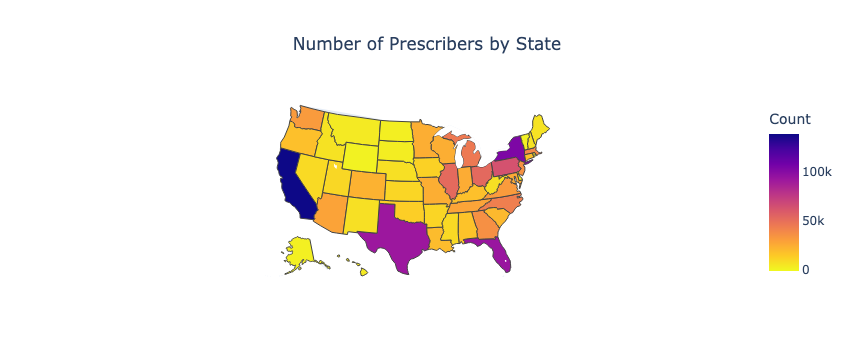

In [123]:
import plotly.express as px

fig = px.choropleth(state_count,
                    locations = 'State',
                    locationmode = 'USA-states',
                    color = 'Count',
                    color_continuous_scale = 'Plasma_r',
                    scope = 'usa',
                    title = 'Number of Prescribers by State'
                   )
fig.update_layout(title_x = 0.5)
fig.show()

In [125]:
con.execute('''
    CREATE TABLE state_pops AS
    SELECT * FROM 'data/NST-EST2023-ALLDATA.csv'
''')

In [472]:
state_pops = con.execute('''
    SELECT NAME,POPESTIMATE2023
    FROM state_pops
    WHERE STATE != 00;
''').df()

# dictionary of state abbreviations and the full name
abbreviation_to_name = {
    # https://en.wikipedia.org/wiki/List_of_states_and_territories_of_the_United_States#States.
    "AK": "Alaska","AL": "Alabama","AR": "Arkansas", "AZ": "Arizona", "CA": "California", "CO": "Colorado","CT": "Connecticut",
    "DE": "Delaware","FL": "Florida","GA": "Georgia","HI": "Hawaii","IA": "Iowa","ID": "Idaho","IL": "Illinois","IN": "Indiana",
    "KS": "Kansas","KY": "Kentucky","LA": "Louisiana","MA": "Massachusetts","MD": "Maryland","ME": "Maine","MI": "Michigan",
    "MN": "Minnesota","MO": "Missouri","MS": "Mississippi","MT": "Montana","NC": "North Carolina","ND": "North Dakota",
    "NE": "Nebraska", "NH": "New Hampshire","NJ": "New Jersey","NM": "New Mexico","NV": "Nevada","NY": "New York","OH": "Ohio",
    "OK": "Oklahoma","OR": "Oregon","PA": "Pennsylvania","RI": "Rhode Island","SC": "South Carolina","SD": "South Dakota",
    "TN": "Tennessee", "TX": "Texas","UT": "Utah","VA": "Virginia","VT": "Vermont","WA": "Washington","WI": "Wisconsin",
    "WV": "West Virginia","WY": "Wyoming",
    # https://en.wikipedia.org/wiki/List_of_states_and_territories_of_the_United_States#Federal_district.
    "DC": "District of Columbia",
    # https://en.wikipedia.org/wiki/List_of_states_and_territories_of_the_United_States#Inhabited_territories.
    "AS": "American Samoa","GU": "Guam GU","MP": "Northern Mariana Islands","PR": "Puerto Rico","VI": "U.S. Virgin Islands",
}

# create new dictionary with full state names as the keys
keys = {v:k for k,v in abbreviation_to_name.items()}

# change state names from full to abbreviated for state population 
state_pops['NAME'] = [keys[state] for state in state_pops['NAME']]
#
non_states = list(list(specialties['State'].unique()) - abbreviation_to_name.keys())

state_count = pd.merge(state_count, state_pops, left_on = 'State', right_on = 'NAME', how = 'left')

In [473]:
state_count['Count_per_100k'] = 100000 * state_count['Count'] / state_count['POPESTIMATE2023']
state_count.to_csv('outputs/state_count.csv', index = False)

In [160]:
state_count.sort_values(by = 'Count_per_100k', ascending = False).head()

,State,Count,NAME,POPESTIMATE2023,Count_per_cap,Count_per_100k
43,DC,5191,DC,678972.0,0.007645,764.538155
9,MA,39945,MA,7001399.0,0.005705,570.528833
24,CT,19551,CT,3617176.0,0.005405,540.504526
1,NY,104092,NY,19571216.0,0.005319,531.862711
42,RI,5750,RI,1095962.0,0.005247,524.653227


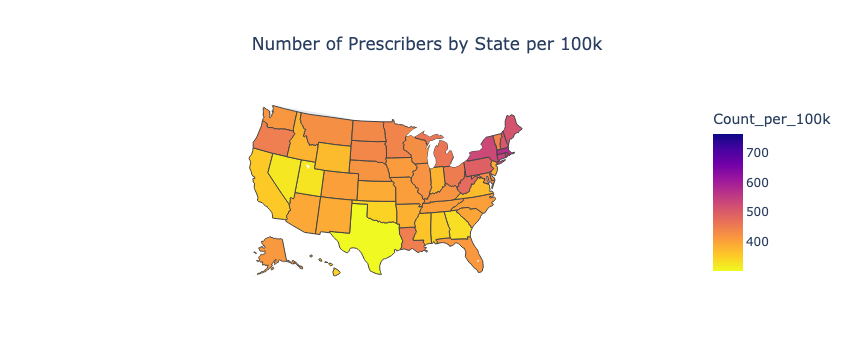

In [161]:
fig = px.choropleth(state_count,
                    locations = 'State',
                    locationmode = 'USA-states',
                    color = 'Count_per_100k',
                    color_continuous_scale = 'Plasma_r',
                    scope = 'usa',
                    title = 'Number of Prescribers by State per 100k'
                   )
fig.update_layout(title_x = 0.5)
fig.show()

In [442]:
specialties = con.execute('''
    SELECT Prscrbr_State_Abrvtn AS State,
        Prscrbr_Type AS Specialty,
        COUNT(1) As Count
    FROM prescribers
    GROUP BY State, Specialty;
''').df()

# remove 
specialties = specialties[~specialties['State'].isin(non_states)]
specialties.sort_values(by = 'Count', ascending = False)


,State,Specialty,Count
4664,FL,Nurse Practitioner,20154
3993,TX,Nurse Practitioner,18854
4000,CA,Dentist,16755
3997,CA,Nurse Practitioner,16006
2000,CA,Internal Medicine,15825
...,...,...,...
3269,WY,Pathology,1
3265,HI,Military Health Care Provider,1
3264,MA,Pharmacy,1
3262,NH,Licensed Professional Counselor,1


In [443]:
specialty_variance = (specialties
    .groupby('Specialty')['Count']
    .agg(['mean', 'std', 'min', 'max'])
    .reset_index()
)

specialty_variance.sort_values('std', ascending=False).head(20)

,Specialty,mean,std,min,max
119,Nurse Practitioner,4619.642857,4689.128736,1,20154
84,Internal Medicine,2289.196429,2979.517303,1,15825
41,Dentist,2386.290909,2951.620143,1,16755
150,Physician Assistant,2352.890909,2682.555813,2,12282
57,Family Practice,2117.909091,2379.521818,6,13471
188,Student in an Organized Health Care Education/...,1257.754717,1931.851393,2,11797
53,Emergency Medicine,1010.851852,1172.898834,6,5995
142,Pharmacist,656.581818,972.138568,1,5761
122,Obstetrics & Gynecology,622.218182,718.507808,1,3713
126,Optometry,603.309091,617.756631,2,3144


In [444]:
print('The amount of times a state has only 1 provider for a particular specialty:',len(specialties[specialties['Count'] == 1]))
print('The amount of times a state has 5 or fewer providers for a particular specialty:',len(specialties[specialties['Count'] <= 5]))

The amount of times a state has only 1 provider for a particular specialty: 783
The amount of times a state has 5 or fewer providers for a particular specialty: 1602


In [445]:
# states with the highest number of occurrences of specialties with only one provider
specialties[specialties['Count'] == 1].groupby(by = 'State').sum()['Count'].sort_values(ascending = False).reset_index().head(10)

,State,Count
0,CA,27
1,FL,27
2,AZ,22
3,OH,21
4,WY,20
5,OK,20
6,OR,20
7,NC,20
8,PR,20
9,MA,20


In [469]:
state_totals = specialties.groupby('State')['Count'].sum().reset_index()
state_totals.columns = ['State', 'state_total']

specialty_totals = specialties.groupby('Specialty')['Count'].sum().reset_index()
specialty_totals.columns = ['Specialty', 'specialty_total']

total = specialties['Count'].sum()

specialties_enriched = (specialties
    .merge(state_totals, on = 'State', how = 'left')
    .merge(specialty_totals, on = 'Specialty', how = 'left')
)

specialties_enriched['expected'] = (
    specialties_enriched['state_total'] * 
    specialties_enriched['specialty_total'] / total
)

specialties_enriched['location_quotient'] = (
    specialties_enriched['Count'] / 
    specialties_enriched['expected']
)

specialties_enriched.to_csv('outputs/specialties_enriched.csv', index = False)
specialties_enriched.head()


,State,Specialty,Count,state_total,specialty_total,expected,location_quotient
0,TN,Nurse Practitioner,8955,29129,258700.0,5459.714236,1.640196
1,WI,Nurse Practitioner,4951,25408,258700.0,4762.278805,1.039628
2,MI,Nurse Practitioner,6978,46434,258700.0,8703.229457,0.801771
3,NY,Internal Medicine,10915,104092,128195.0,9667.993453,1.128983
4,MO,Internal Medicine,2373,25377,128195.0,2356.998327,1.006789


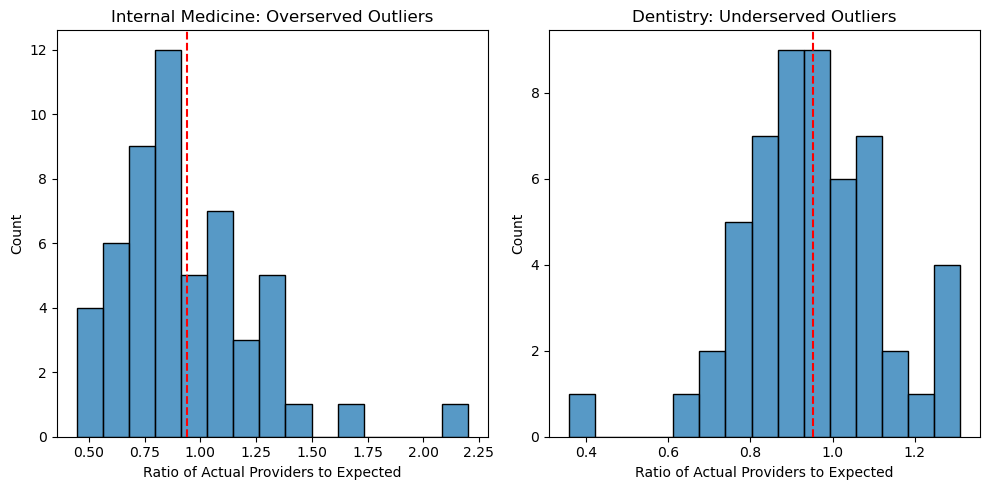

In [468]:
# underserved states based on expected number of practitioners by state
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

IM = specialties_enriched[(specialties_enriched['expected'] > 5) & (specialties_enriched['Specialty'] == 'Internal Medicine')].sort_values(by = 'location_quotient',ascending = True)
IM_plot = sns.histplot(IM,
             x = 'location_quotient', 
             bins = 15,
             ax = axes[0])
IM_plot.axvline(IM['location_quotient'].mean(), color = 'red',linestyle = 'dashed')
IM_plot.set_title('Internal Medicine: Overserved Outliers')
IM_plot.set_xlabel('Ratio of Actual Providers to Expected')


dentists = specialties_enriched[(specialties_enriched['expected'] > 5) & (specialties_enriched['Specialty'] == 'Dentist')].sort_values(by = 'location_quotient',ascending = True)
dent_plot = sns.histplot(dentists,
             x = 'location_quotient',
             bins = 15,
             ax = axes[1])
dent_plot.axvline(dentists['location_quotient'].mean(), color = 'red',linestyle = 'dashed')
dent_plot.set_title('Dentistry: Underserved Outliers')
dent_plot.set_xlabel('Ratio of Actual Providers to Expected')

plt.tight_layout()
IM.to_csv('outputs/IM.csv',index = False)
dentists.to_csv('outputs/dentists.csv', index = False)

In [448]:
IM_iqr = IM['location_quotient'].quantile(.75) - IM['location_quotient'].quantile(.25)
IM_lower = IM['location_quotient'].quantile(.25) - 1.5 * IM_iqr
IM_upper = IM['location_quotient'].quantile(.75) + 1.5 * IM_iqr
print(IM_lower,IM_upper)

print(IM[(IM['location_quotient'] > IM_upper) | (IM['location_quotient'] < IM_lower)][['State','location_quotient']])

dent_iqr = dentists['location_quotient'].quantile(.75) - dentists['location_quotient'].quantile(.25)
dent_lower = dentists['location_quotient'].quantile(.25) - 1.5 * dent_iqr
dent_upper = dentists['location_quotient'].quantile(.75) + 1.5 * dent_iqr
print(dent_lower,dent_upper)

print(dentists[(dentists['location_quotient'] > dent_upper) | (dentists['location_quotient'] < dent_lower)][['State','location_quotient']])


0.21292212859533743 1.6426986765509608
     State  location_quotient
2004    RI           1.703941
961     GU           2.202271
0.5218353507060487 1.3913294406328276
     State  location_quotient
3754    GU           0.358513


In [482]:
underserved_dict = {}

for specialty in list(specialties_enriched['Specialty'].unique()):
    under_array = specialties_enriched[specialties_enriched['Specialty'] == specialty]['location_quotient']
    iqr = under_array.quantile(.75) - under_array.quantile(.25)
    lower = under_array.quantile(.25) - 1.5 * iqr
    underserved_state_list = list(specialties_enriched[(specialties_enriched['Specialty'] == specialty) & (specialties_enriched['location_quotient'] < lower)]['State'])
    if underserved_state_list: underserved_dict[specialty] = underserved_state_list
    else: pass
for key in underserved_dict:
    print(f"{key}: {underserved_dict[key]}")


Nurse Practitioner: ['PR']
Dentist: ['GU', 'MP']
Optometry: ['PR', 'DC']
Physician Assistant: ['PR']
Urology: ['NM', 'ND']
Ophthalmology: ['WY']
Plastic and Reconstructive Surgery: ['WY']
Oral Surgery (Dentist only): ['WV']
Pulmonary Disease: ['AK', 'WY']
Orthopedic Surgery: ['PR']
Radiation Oncology: ['PR']
Neurosurgery: ['VT']
Allergy/ Immunology: ['WY']
Hand Surgery: ['WV']
Surgical Oncology: ['ID']
Phlebology: ['FL']


In [540]:
underserved_dict = {'State':[],'Specialty':[]}

for specialty in list(specialties_enriched['Specialty'].unique()):
    under_array = specialties_enriched[specialties_enriched['Specialty'] == specialty]['location_quotient']
    iqr = under_array.quantile(.75) - under_array.quantile(.25)
    lower = under_array.quantile(.25) - 1.5 * iqr
    ls = list(specialties_enriched[(
        specialties_enriched['Specialty'] == specialty) & (
        specialties_enriched['location_quotient'] < lower)]['State']
             )
    if len(ls) > 0:
        for state in ls:
            underserved_dict['State'].append(state)
            underserved_dict['Specialty'].append(specialty)
        else: pass

print(underserved_dict)
underserved_df = pd.DataFrame.from_dict(underserved_dict)
underserved_df = underserved_df.merge(underserved_df.groupby('State').agg(Count = ('State','count')), on = 'State')
underserved_df

{'State': ['PR', 'GU', 'MP', 'PR', 'DC', 'PR', 'NM', 'ND', 'WY', 'WY', 'WV', 'AK', 'WY', 'PR', 'PR', 'VT', 'WY', 'WV', 'ID', 'FL'], 'Specialty': ['Nurse Practitioner', 'Dentist', 'Dentist', 'Optometry', 'Optometry', 'Physician Assistant', 'Urology', 'Urology', 'Ophthalmology', 'Plastic and Reconstructive Surgery', 'Oral Surgery (Dentist only)', 'Pulmonary Disease', 'Pulmonary Disease', 'Orthopedic Surgery', 'Radiation Oncology', 'Neurosurgery', 'Allergy/ Immunology', 'Hand Surgery', 'Surgical Oncology', 'Phlebology']}


,State,Specialty,Count
0,PR,Nurse Practitioner,5
1,GU,Dentist,1
2,MP,Dentist,1
3,PR,Optometry,5
4,DC,Optometry,1
5,PR,Physician Assistant,5
6,NM,Urology,1
7,ND,Urology,1
8,WY,Ophthalmology,4
9,WY,Plastic and Reconstructive Surgery,4


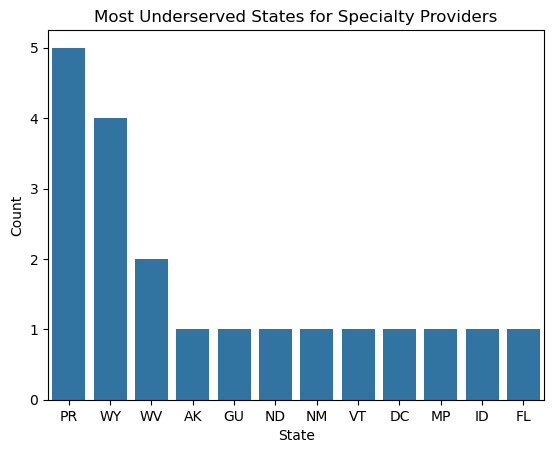

In [543]:
sns.barplot(data = underserved_df,
            x = 'State',
            y = 'Count',
            order = underserved_df.sort_values(by = 'Count', ascending = False)['State'])
plt.title('Most Underserved States for Specialty Providers')
plt.show()
undercounted_df.to_csv('outputs/underserved_states.csv',index = False)

In [452]:
pr_specialties = [specialty for specialty, states in underserved_dict.items() if 'PR' in states]
specialties_enriched[(specialties_enriched['State'] == 'PR') & (specialties_enriched['Specialty'].isin(pr_specialties))]


,State,Specialty,Count,state_total,specialty_total,expected,location_quotient
431,PR,Physician Assistant,2,11379,129409.0,1066.882242,0.001875
929,PR,Optometry,10,11379,33182.0,273.561240,0.036555
2390,PR,Nurse Practitioner,6,11379,258700.0,2132.791661,0.002813
2714,PR,Orthopedic Surgery,112,11379,21056.0,173.591269,0.645194
4324,PR,Radiation Oncology,19,11379,4884.0,40.264996,0.471874


In [466]:
pr_gaps = specialties_enriched[
    (specialties_enriched['State'] == 'PR') &
    (specialties_enriched['Specialty'].isin(pr_specialties))
].copy()

pr_gaps['providers_needed'] = (
    pr_gaps['expected'] - pr_gaps['Count']
).round(0)

pr_gaps.sort_values('location_quotient')
pr_gaps.to_csv('outputs/pr_gaps.csv', index = False)

In [463]:
underserved = specialties_enriched[
    specialties_enriched['location_quotient'] < 0.5
].groupby('State').agg(
    gap_count=('Specialty', 'count'),
    avg_lq=('location_quotient', 'mean')
).reset_index().sort_values('gap_count', ascending=False)

underserved.head(10)
underserved.to_csv('outputs/underserved.csv', index = False)

In [465]:
pr_cost = con.execute('''
    SELECT 
        d.Prscrbr_State_Abrvtn AS State,
        d.Prscrbr_Type AS Specialty,
        SUM(d.Tot_Drug_Cst) AS total_cost,
        SUM(d.Tot_Clms) AS total_claims,
        ROUND(SUM(d.Tot_Drug_Cst) / NULLIF(SUM(d.Tot_Clms), 0), 2) 
            AS cost_per_claim
    FROM drugs d
    WHERE d.Prscrbr_State_Abrvtn = 'PR'
    GROUP BY State, Specialty
    ORDER BY cost_per_claim DESC
''').df()
pr_cost.to_csv('outputs/pr_cost.csv', index = False)

In [464]:
national_avg = con.execute('''
    SELECT
        d.Prscrbr_Type AS Specialty,
        SUM(d.Tot_Drug_Cst) AS total_cost,
        SUM(d.Tot_Clms) AS total_claims,
        ROUND(SUM(d.Tot_Drug_Cst) / NULLIF(SUM(d.Tot_Clms), 0), 2) AS cost_per_claim
    FROM drugs d
    GROUP BY Specialty
    ORDER BY cost_per_claim DESC
''').df()
national_avg.to_csv('outputs/national_avg.csv', index = False)

In [458]:
# compare PR cost-per-claim with national average
pr_comparison = pr_cost.merge(national_avg,
              on = 'Specialty',
              how = 'left',
              suffixes = ('_PR','_national'))
pr_comparison['cost_per_claim_diff'] = pr_comparison['cost_per_claim_PR'] - pr_comparison['cost_per_claim_national']
pr_comparison[pr_comparison['Specialty'].isin(pr_specialties)].sort_values(by = 'cost_per_claim_diff', ascending = False)

,State,Specialty,total_cost_PR,total_claims_PR,cost_per_claim_PR,total_cost_national,total_claims_national,cost_per_claim_national,cost_per_claim_diff
1,PR,Nurse Practitioner,2363141.55,818.0,2888.93,3.297548e+10,235237890.0,140.18,2748.75
14,PR,Optometry,206007.62,1071.0,192.35,1.225340e+09,6952849.0,176.24,16.11
74,PR,Orthopedic Surgery,1604864.31,75933.0,21.14,1.179337e+08,6554688.0,17.99,3.15
34,PR,Physician Assistant,4807.77,62.0,77.54,1.186239e+10,84261318.0,140.78,-63.24
81,PR,Radiation Oncology,33855.02,2157.0,15.70,1.192263e+08,610402.0,195.32,-179.62


In [462]:
# check for specialties that aren't outliers
pr_comparison[~pr_comparison['Specialty'].isin(pr_specialties)].sort_values(by = 'cost_per_claim_diff', ascending = False).head(10)
pr_comparison.to_csv('outputs/pr_comparison.csv', index = False)